# 01 — Exploratory Data Analysis: Avocado Prices

This notebook performs an initial exploration of the **Hass Avocado Board** dataset (`avocado.csv`).

**Goals**
1. Load the raw data and inspect its structure.
2. Understand column types, missing values, and basic statistics.
3. Visualise price distributions, trends over time, and regional differences.
4. Document any data-quality issues to address in later preprocessing.

**Dataset columns**
| Column | Description |
|---|---|
| `Date` | Observation date (weekly) |
| `AveragePrice` | Average retail price of a single avocado |
| `Total Volume` | Total number of avocados sold |
| `4046` / `4225` / `4770` | Volume sold by PLU code (size) |
| `Total Bags` / `Small Bags` / `Large Bags` / `XLarge Bags` | Volume sold in bags |
| `type` | Conventional or organic |
| `year` | Year of observation |
| `region` | City or region of the observation |

## 1. Imports & Configuration

In [1]:
import os, sys, importlib.util
print('cwd:', os.getcwd())
print('sys.executable:', sys.executable)
print('first 5 sys.path entries:')
for p in sys.path[:5]:
    print(' -', p)
spec = importlib.util.find_spec('numpy')
print('numpy spec origin:', spec.origin if spec else None)
import numpy as np
print('numpy imported from:', np.__file__)
print('numpy version:', np.__version__)

cwd: c:\Users\yagoc\OneDrive\Escritorio\pite\pite_py_projects\pricing-engine\notebooks
sys.executable: c:\Users\yagoc\OneDrive\Escritorio\Pite\pite_py_projects\pricing-engine\.venv\Scripts\python.exe
first 5 sys.path entries:
 - C:\Users\yagoc\AppData\Local\Programs\Python\Python311\python311.zip
 - C:\Users\yagoc\AppData\Local\Programs\Python\Python311\DLLs
 - C:\Users\yagoc\AppData\Local\Programs\Python\Python311\Lib
 - C:\Users\yagoc\AppData\Local\Programs\Python\Python311
 - c:\Users\yagoc\OneDrive\Escritorio\Pite\pite_py_projects\pricing-engine\.venv
numpy spec origin: c:\Users\yagoc\OneDrive\Escritorio\Pite\pite_py_projects\pricing-engine\.venv\Lib\site-packages\numpy\__init__.py
numpy imported from: c:\Users\yagoc\OneDrive\Escritorio\Pite\pite_py_projects\pricing-engine\.venv\Lib\site-packages\numpy\__init__.py
numpy version: 1.26.4


In [2]:
# Core data handling
import pandas as pd
import numpy as np
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display helpers
from IPython.display import display, Markdown

# ---------- Plot style ----------
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)

# ---------- Paths ----------
DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
DATA_OUTPUTS = Path("../data/outputs")

print("✔ Imports loaded successfully")

✔ Imports loaded successfully


## 2. Load the Raw Data

Read `avocado.csv` and perform a quick sanity check: shape, first rows, and column types.

In [3]:
# Load dataset — the first unnamed column is the original row index, so we drop it
df = pd.read_csv(DATA_RAW / "avocado.csv", index_col=0)

# Parse the Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date for consistent time-series operations
df = df.sort_values("Date").reset_index(drop=True)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 18,249 rows × 13 columns


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-01-04,1.75,27365.89,9307.34,3844.81,615.28,13598.46,13061.10,537.36,0.0,organic,2015,Southeast
1,2015-01-04,1.49,17723.17,1189.35,15628.27,0.00,905.55,905.55,0.00,0.0,organic,2015,Chicago
2,2015-01-04,1.68,2896.72,161.68,206.96,0.00,2528.08,2528.08,0.00,0.0,organic,2015,HarrisburgScranton
3,2015-01-04,1.52,54956.80,3013.04,35456.88,1561.70,14925.18,11264.80,3660.38,0.0,conventional,2015,Pittsburgh
4,2015-01-04,1.64,1505.12,1.27,1129.50,0.00,374.35,186.67,187.68,0.0,organic,2015,Boise


## 3. Data Overview

Check column data types, memory usage, and missing values.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          18249 non-null  datetime64[ns]
 1   AveragePrice  18249 non-null  float64       
 2   Total Volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   Total Bags    18249 non-null  float64       
 7   Small Bags    18249 non-null  float64       
 8   Large Bags    18249 non-null  float64       
 9   XLarge Bags   18249 non-null  float64       
 10  type          18249 non-null  object        
 11  year          18249 non-null  int64         
 12  region        18249 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 1.8+ MB


In [5]:
# Missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("No missing values found.")
else:
    display(missing.to_frame("missing_count"))

No missing values found.


In [6]:
# Descriptive statistics for numeric columns
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,18249,2016-08-13 23:30:43.498273792,2015-01-04 00:00:00,2015-10-25 00:00:00,2016-08-14 00:00:00,2017-06-04 00:00:00,2018-03-25 00:00:00,NaN
AveragePrice,18249.0,1.405978,0.44,1.1,1.37,1.66,3.25,0.402677
Total Volume,18249.0,850644.013009,84.56,10838.58,107376.76,432962.29,62505646.52,3453545.355399
4046,18249.0,293008.424531,0.0,854.07,8645.3,111020.2,22743616.17,1264989.081763
4225,18249.0,295154.568356,0.0,3008.78,29061.02,150206.86,20470572.61,1204120.401135
4770,18249.0,22839.735993,0.0,0.0,184.99,6243.42,2546439.11,107464.068435
Total Bags,18249.0,239639.20206,0.0,5088.64,39743.83,110783.37,19373134.37,986242.399216
Small Bags,18249.0,182194.686696,0.0,2849.42,26362.82,83337.67,13384586.8,746178.514962
Large Bags,18249.0,54338.088145,0.0,127.47,2647.71,22029.25,5719096.61,243965.964547
XLarge Bags,18249.0,3106.426507,0.0,0.0,0.0,132.5,551693.65,17692.894652


In [7]:
# Categorical columns — unique values
print(f"Types     : {df['type'].unique()}")
print(f"Years     : {sorted(df['year'].unique())}")
print(f"Regions   : {df['region'].nunique()} unique regions")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

Types     : ['organic' 'conventional']
Years     : [2015, 2016, 2017, 2018]
Regions   : 54 unique regions
Date range: 2015-01-04 → 2018-03-25


## 4. Price Distribution

Visualise how `AveragePrice` is distributed overall and split by avocado type.

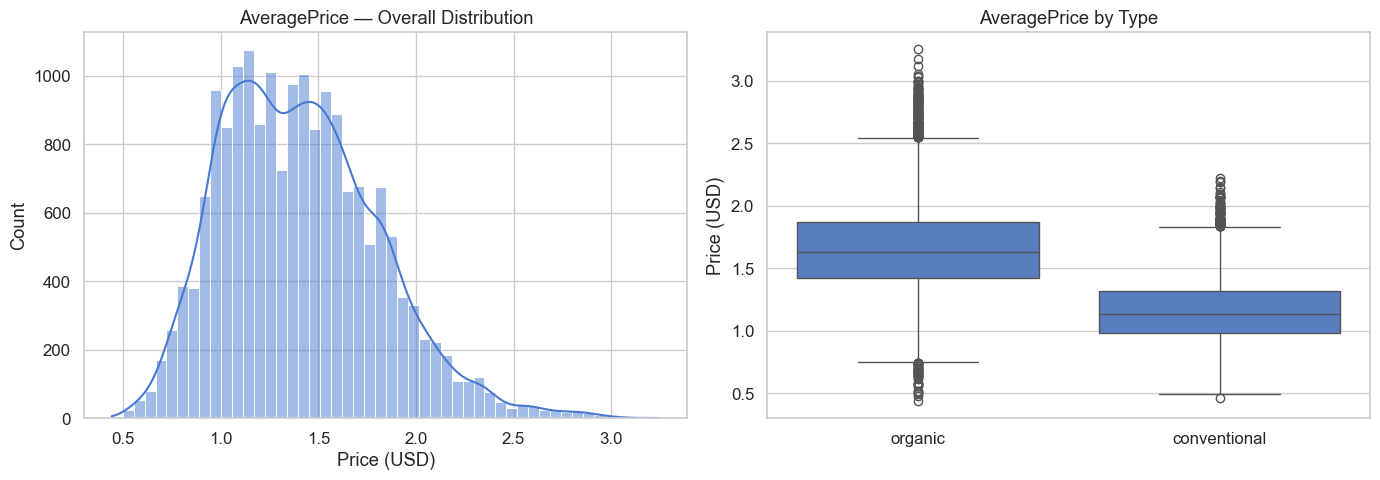

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
sns.histplot(df["AveragePrice"], kde=True, bins=50, ax=axes[0])
axes[0].set_title("AveragePrice — Overall Distribution")
axes[0].set_xlabel("Price (USD)")

# By type
sns.boxplot(data=df, x="type", y="AveragePrice", ax=axes[1])
axes[1].set_title("AveragePrice by Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Price (USD)")

plt.tight_layout()
plt.show()

## 5. Price Trends Over Time

Plot weekly average price aggregated across all regions, split by type.

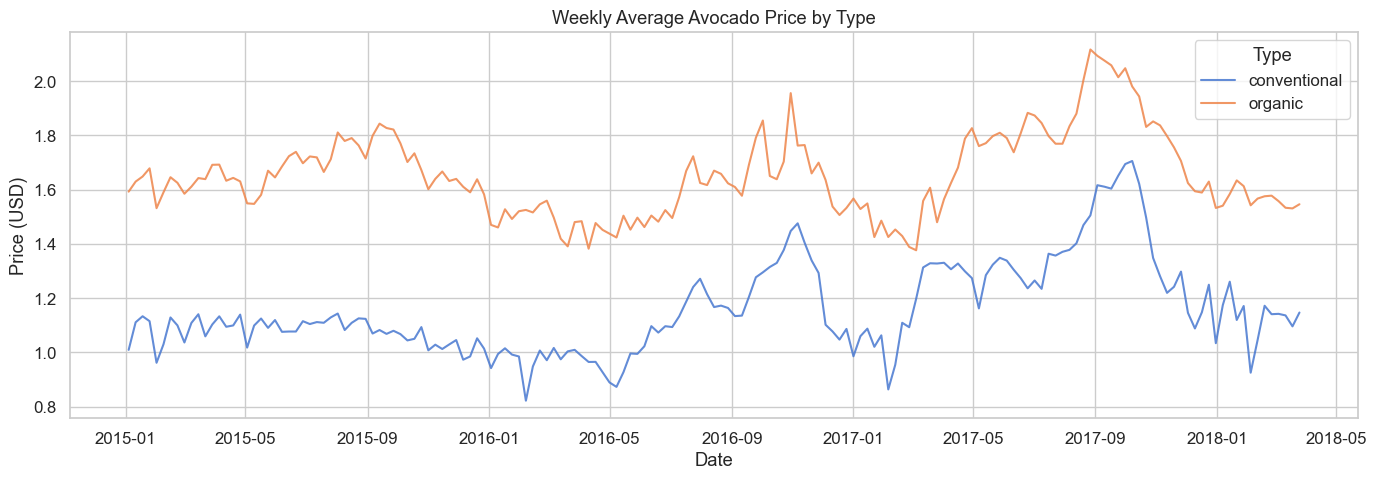

In [9]:
# Weekly average price by type (aggregated across regions)
weekly_price = (
    df.groupby(["Date", "type"])["AveragePrice"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for avocado_type, group in weekly_price.groupby("type"):
    ax.plot(group["Date"], group["AveragePrice"], label=avocado_type, alpha=0.85)

ax.set_title("Weekly Average Avocado Price by Type")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(title="Type")
plt.tight_layout()
plt.show()

## 6. Volume Analysis

Explore total volume sold and how it relates to price.

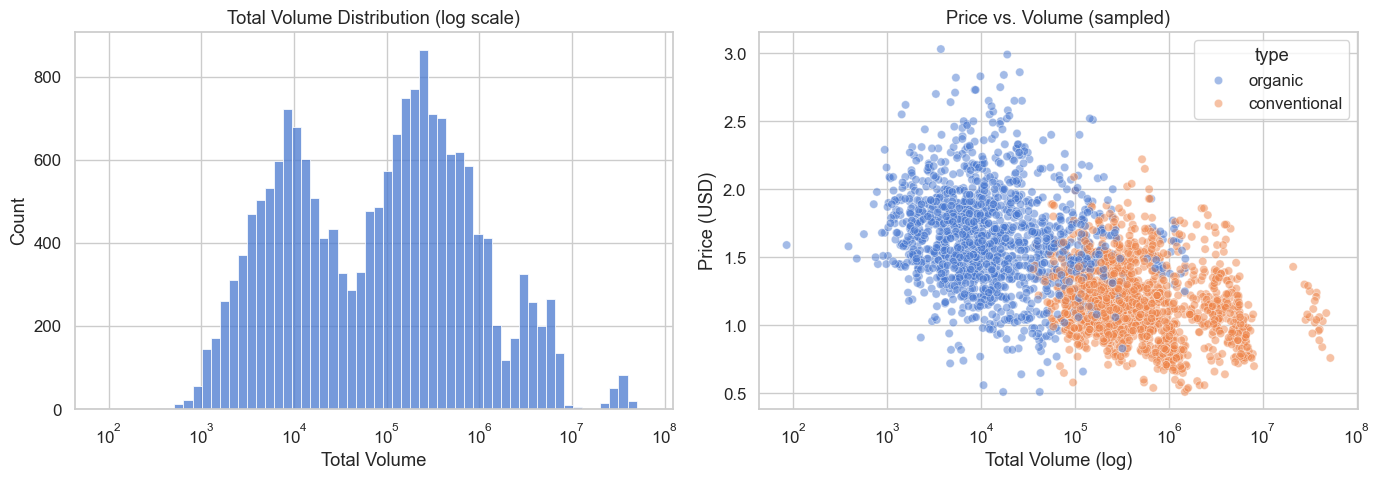

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume distribution (log scale for readability)
sns.histplot(df["Total Volume"], bins=60, log_scale=True, ax=axes[0])
axes[0].set_title("Total Volume Distribution (log scale)")
axes[0].set_xlabel("Total Volume")

# Price vs Volume scatter
sns.scatterplot(
    data=df.sample(3000, random_state=42),
    x="Total Volume", y="AveragePrice",
    hue="type", alpha=0.5, ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("Price vs. Volume (sampled)")
axes[1].set_xlabel("Total Volume (log)")
axes[1].set_ylabel("Price (USD)")

plt.tight_layout()
plt.show()

## 7. Regional Comparison

Compare average prices across the top 15 regions by volume.

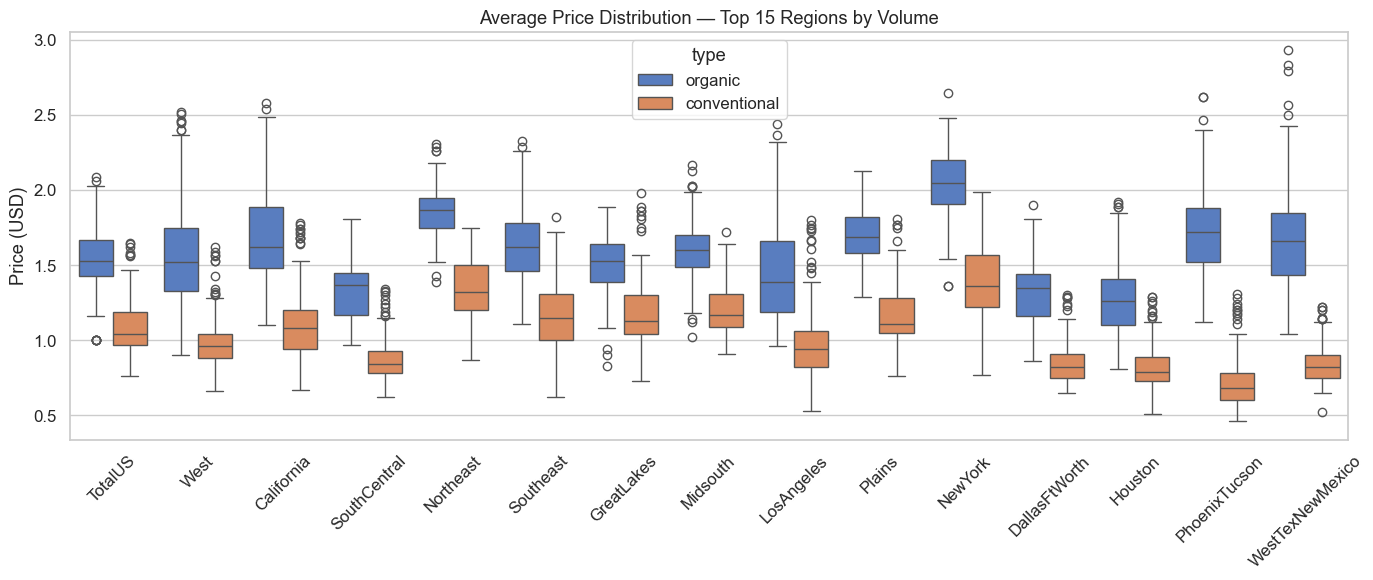

In [11]:
# Top 15 regions by total volume
top_regions = (
    df.groupby("region")["Total Volume"]
    .sum()
    .nlargest(15)
    .index
)

df_top = df[df["region"].isin(top_regions)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_top, x="region", y="AveragePrice",
    hue="type", order=top_regions, ax=ax,
)
ax.set_title("Average Price Distribution — Top 15 Regions by Volume")
ax.set_xlabel("")
ax.set_ylabel("Price (USD)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 8. Correlation Heatmap

Examine linear relationships between numeric features.

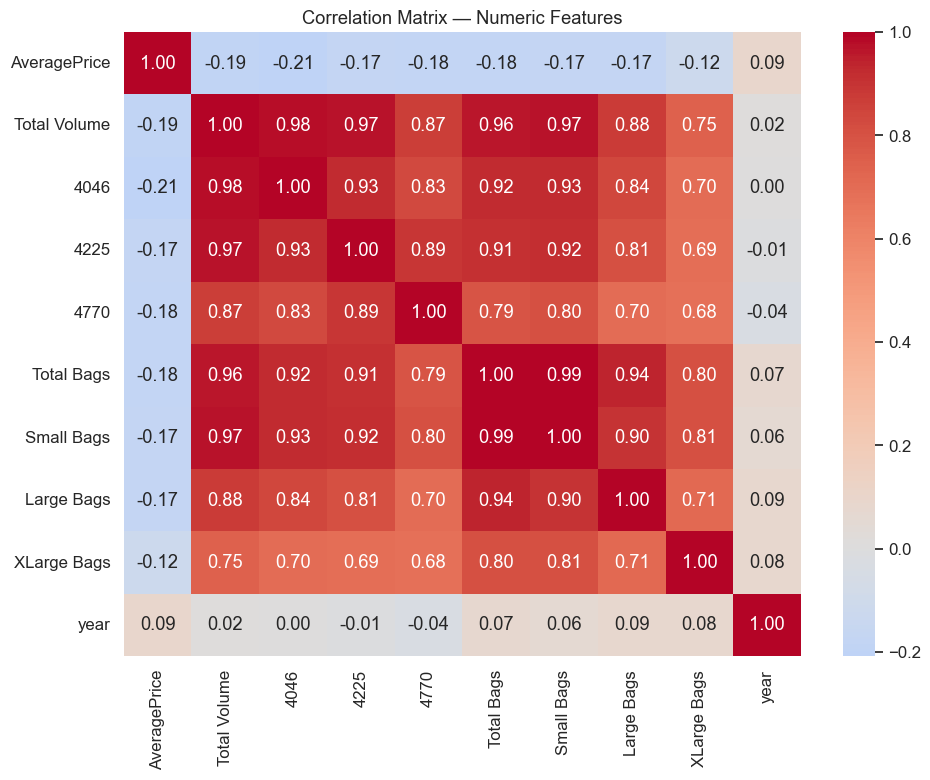

In [12]:
numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

## Next Steps

Key observations to carry into **02_feature_engineering.ipynb**:

- **Organic avocados** are consistently more expensive than conventional ones.
- Volume features are highly right-skewed — consider **log transforms**.
- Bag-related columns are strongly correlated with each other — may warrant **aggregation or feature selection**.
- The `region` column contains both cities and aggregate regions (e.g. `TotalUS`) — filter or encode carefully.
- The `year` column is redundant with `Date` — can be dropped after extracting richer time features.